# Week 14: Training AI Models — Fine-Tuning a Fraud Classifier

## Learning Objectives

By the end of this session, you will be able to:
1. **Prepare text data** for fine-tuning with HuggingFace tokenizers and datasets
2. **Fine-tune DistilBERT** for binary classification using transfer learning
3. **Evaluate fine-tuned models** against prompted models from previous weeks
4. **Decide when to fine-tune** vs when prompt engineering is sufficient

## Prerequisites

- Completed Weeks 11-13 (LLM APIs, local models, evaluation, Bedrock, synthetic data)
- Watched pre-class videos on fine-tuning concepts, transfer learning, LoRA/QLoRA theory
- Synthetic training data from Week 13 Lab 3 (or we'll generate fallback data)

## Session Format (~2 hours)

| Section | Duration | Type |
|---------|----------|------|
| Section 0: Setup & Load Data | 10 min | Code |
| Section 1: Transfer Learning Concepts | 15 min | Theory + Demo |
| Section 2: Tokenization & Data Prep | 20 min | Demo |
| Lab 1: Prepare Your Dataset | 15 min | Lab |
| Section 3: Fine-Tuning DistilBERT | 25 min | Demo-heavy |
| Lab 2: Fine-Tune Your Classifier | 15 min | Lab |
| Section 4: Evaluation & Decision Framework | 15 min | Demo + Theory |
| Wrap-up & Homework | 5 min | Markdown |

## What We'll Build Today

![Week 14 Overview Pipeline](https://github.com/axel-sirota/bread-financial-academy/blob/main/exercises/week_14_training_ai_models/charts/overview_pipeline.png?raw=1)

**The punchline**: Fine-tuning a small model on synthetic data gives you
~90%+ accuracy at a fraction of the cost — FREE at inference, fast, and private.

## GPU Setup

**Runtime > Change runtime type > T4 GPU** (recommended for faster training)

# Section 0: Environment Setup

We'll use HuggingFace Transformers for model fine-tuning and the datasets
library for efficient data handling. GPU is recommended but not strictly required.

In [1]:
# =============================================================================
# INSTALL REQUIRED LIBRARIES
# =============================================================================
# transformers: HuggingFace models and Trainer
# datasets: Efficient dataset handling
# accelerate: Optimized training on GPU
# scikit-learn: Evaluation metrics (precision, recall, F1)
# evaluate: HuggingFace evaluate library

!pip install -q transformers datasets accelerate scikit-learn evaluate

# =============================================================================
# IMPORTS
# =============================================================================
import torch
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    Trainer,
    TrainingArguments,
    DataCollatorWithPadding,
)
from datasets import Dataset, DatasetDict
from sklearn.metrics import (
    accuracy_score, precision_recall_fscore_support,
    confusion_matrix, classification_report, ConfusionMatrixDisplay
)
from sklearn.model_selection import train_test_split
import evaluate
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import json
import os

# =============================================================================
# VERIFY INSTALLATIONS
# =============================================================================
print("Library versions:")
print(f"  PyTorch:       {torch.__version__}")
print(f"  GPU available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"  GPU device:    {torch.cuda.get_device_name(0)}")
    print(f"  GPU memory:    {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
print("\n✅ All libraries installed successfully!")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 8.9 MB/s eta 0:00:00
Library versions:
  PyTorch:       2.10.0+cu128
  GPU available: True
  GPU device:    Tesla T4
  GPU memory:    15.6 GB

✅ All libraries installed successfully!


In [2]:
# =============================================================================
# TEST DATA — 50 Transactions from Week 13 (NEVER used for training)
# =============================================================================
# These are our held-out test set. We'll use them to evaluate the fine-tuned
# model and compare against all previous approaches.

test_transactions = [
    {"id": "TXN-001", "description": "Customer reports unauthorized wire transfer of $4,500 to unknown overseas account. No prior international transaction history. Transfer initiated at 3:47 AM local time.", "actual_label": "fraud"},
    {"id": "TXN-002", "description": "Regular monthly payment of $89.99 to Netflix streaming service. Consistent with 18-month subscription history. Payment from primary checking account.", "actual_label": "legitimate"},
    {"id": "TXN-003", "description": "Three consecutive ATM withdrawals totaling $1,500 in different cities within 2 hours. Card was reported lost the following day. Withdrawals at non-bank ATMs.", "actual_label": "fraud"},
    {"id": "TXN-004", "description": "Online purchase of $234.56 at Amazon.com for household electronics. Shipping to address on file. Customer has frequent Amazon purchase history.", "actual_label": "legitimate"},
    {"id": "TXN-005", "description": "Customer disputes charge of $2,100 at luxury jewelry store in Miami. Customer's location confirmed as Chicago at time of purchase. No travel alerts set.", "actual_label": "fraud"},
    {"id": "TXN-006", "description": "Automatic payroll direct deposit of $3,245.67 from employer ABC Corp. Matches bi-weekly pay schedule. Amount consistent with employment records.", "actual_label": "legitimate"},
    {"id": "TXN-007", "description": "Multiple small online purchases ($5-$15) at various digital stores within 30 minutes. None of these merchants appear in customer's history. Different IP addresses used.", "actual_label": "fraud"},
    {"id": "TXN-008", "description": "Grocery purchase of $67.23 at Whole Foods Market. Customer shops here weekly based on 2-year transaction history. Paid with debit card at POS terminal.", "actual_label": "legitimate"},
    {"id": "TXN-009", "description": "Account password changed and $8,200 transferred to a new payee within 15 minutes. Login originated from an IP address in a different country than the account holder's residence.", "actual_label": "fraud"},
    {"id": "TXN-010", "description": "Credit card used for $3,400 purchase at electronics store in Lagos, Nigeria. Cardholder has never traveled outside the United States. Card was not reported stolen.", "actual_label": "fraud"},
    {"id": "TXN-011", "description": "Five gift card purchases of $500 each at different Walmart locations within one hour. Customer has no prior gift card purchase history. All purchases made with the same debit card.", "actual_label": "fraud"},
    {"id": "TXN-012", "description": "Online gambling deposit of $2,000 to an unlicensed offshore betting site. Customer's account shows no prior gambling-related transactions. Deposit made at 4:12 AM.", "actual_label": "fraud"},
    {"id": "TXN-013", "description": "Wire transfer of $15,000 to a recently created account at a foreign bank. Transfer requested via phone call, but customer's voice did not match voiceprint on file.", "actual_label": "fraud"},
    {"id": "TXN-014", "description": "Rapid succession of 12 declined transactions followed by one approved transaction of $1,899 at an electronics retailer. Different card numbers attempted from same IP.", "actual_label": "fraud"},
    {"id": "TXN-015", "description": "Customer's debit card used for contactless payment of $750 at a gas station in Texas while customer was checked into a hotel in New York. No travel notification on file.", "actual_label": "fraud"},
    {"id": "TXN-016", "description": "Account drained of $6,300 through a series of Zelle transfers to three unknown recipients within 20 minutes. Customer claims they did not authorize the transfers.", "actual_label": "fraud"},
    {"id": "TXN-017", "description": "Purchase of $4,200 in cryptocurrency from an unregulated exchange using a newly added payment method. Account security questions were changed 30 minutes prior.", "actual_label": "fraud"},
    {"id": "TXN-018", "description": "Two simultaneous transactions: $1,100 at a restaurant in London and $890 at a store in Sydney. Physical card required at both locations. Cardholder resides in Boston.", "actual_label": "fraud"},
    {"id": "TXN-019", "description": "Refund of $2,500 processed to a different card than the original purchase. Original purchase was made 8 months ago. Refund requested through customer service chat.", "actual_label": "fraud"},
    {"id": "TXN-020", "description": "Cash advance of $3,000 at an ATM in a high-risk neighborhood at 2:30 AM. Customer's account has never had a cash advance. PIN was entered correctly on first attempt.", "actual_label": "fraud"},
    {"id": "TXN-021", "description": "Online purchase of $5,600 worth of designer handbags from a suspicious website with no SSL certificate. Shipping address differs from billing address and is a P.O. box.", "actual_label": "fraud"},
    {"id": "TXN-022", "description": "Authorized user added to account and immediately made a $7,500 purchase. The authorized user's identity could not be verified through standard KYC checks.", "actual_label": "fraud"},
    {"id": "TXN-023", "description": "Series of micro-transactions ($0.01 to $1.00) at 15 different online merchants within 5 minutes. Pattern consistent with card testing before a larger fraudulent purchase.", "actual_label": "fraud"},
    {"id": "TXN-024", "description": "Balance transfer of $12,000 to a new credit card opened the same day. Application used a slightly different spelling of the customer's name and a different phone number.", "actual_label": "fraud"},
    {"id": "TXN-025", "description": "Purchase of $950 airline ticket to a one-way international destination booked 2 hours before departure. Customer has no passport on file and no prior international travel.", "actual_label": "fraud"},
    {"id": "TXN-026", "description": "Monthly mortgage payment of $1,847.33 to Wells Fargo Home Mortgage. Amount unchanged for 3 years. Auto-debit from primary checking account on the 1st of each month.", "actual_label": "legitimate"},
    {"id": "TXN-027", "description": "Quarterly insurance premium of $412.00 to State Farm. Consistent with 5-year policy history. Payment matches scheduled auto-pay date.", "actual_label": "legitimate"},
    {"id": "TXN-028", "description": "Gas station purchase of $52.18 at Shell on Highway 101. Customer fills up at this location every Friday afternoon. Debit card used at pump with PIN.", "actual_label": "legitimate"},
    {"id": "TXN-029", "description": "Online subscription renewal of $14.99 for Spotify Premium. Same charge every month for the past 2 years. Billed to Visa ending in 4532.", "actual_label": "legitimate"},
    {"id": "TXN-030", "description": "Restaurant charge of $78.45 at Olive Garden in customer's hometown. Tip of 20% added. Customer dines here approximately twice per month.", "actual_label": "legitimate"},
    {"id": "TXN-031", "description": "Utility bill payment of $156.78 to ConEdison via online banking. Amount within normal seasonal range. Payment made 3 days before due date as usual.", "actual_label": "legitimate"},
    {"id": "TXN-032", "description": "Daycare tuition payment of $1,200.00 to Little Stars Learning Center. Same amount every two weeks since January. Matches enrollment records.", "actual_label": "legitimate"},
    {"id": "TXN-033", "description": "Pharmacy purchase of $23.45 at CVS near customer's home address. Customer has weekly prescription pickups at this location. Paid with FSA debit card.", "actual_label": "legitimate"},
    {"id": "TXN-034", "description": "Annual gym membership renewal of $599.00 at Planet Fitness. Same charge last year at the same time. Customer checks in 4-5 times per week.", "actual_label": "legitimate"},
    {"id": "TXN-035", "description": "Transfer of $500.00 to savings account at same bank. Customer makes this transfer on the 15th of every month. Part of automatic savings plan.", "actual_label": "legitimate"},
    {"id": "TXN-036", "description": "Online order of $145.67 at Target.com. Shipping to home address on file. Customer has Target Circle membership and shops online monthly.", "actual_label": "legitimate"},
    {"id": "TXN-037", "description": "Car payment of $423.56 to Toyota Financial Services. Amount matches lease agreement. Auto-pay set up 18 months ago, never missed a payment.", "actual_label": "legitimate"},
    {"id": "TXN-038", "description": "Coffee shop purchase of $6.75 at Starbucks near customer's office. Customer visits this location every weekday morning. Mobile order via app.", "actual_label": "legitimate"},
    {"id": "TXN-039", "description": "Charitable donation of $100.00 to American Red Cross. Customer makes this donation annually in December. Tax-deductible receipt issued.", "actual_label": "legitimate"},
    {"id": "TXN-040", "description": "Veterinary bill of $287.50 at Banfield Pet Hospital. Customer has a pet wellness plan. Visit scheduled 2 weeks ago for annual checkup.", "actual_label": "legitimate"},
    {"id": "TXN-041", "description": "Home improvement purchase of $342.89 at Home Depot. Customer recently purchased a home and has made 6 Home Depot purchases in the past month. In-store chip payment.", "actual_label": "legitimate"},
    {"id": "TXN-042", "description": "Monthly student loan payment of $567.89 to Navient. Same amount for 4 years. Auto-debit on the 5th of each month from checking account.", "actual_label": "legitimate"},
    {"id": "TXN-043", "description": "Dry cleaning pickup charge of $34.50 at Express Cleaners. Customer drops off clothes every Monday and picks up Wednesday. Store is 2 blocks from home.", "actual_label": "legitimate"},
    {"id": "TXN-044", "description": "Online purchase of $89.99 for annual antivirus software renewal from Norton. Same charge last year. License key sent to email on file.", "actual_label": "legitimate"},
    {"id": "TXN-045", "description": "Ride-share charge of $24.67 from Uber. Trip from customer's office to home address. Customer uses Uber 2-3 times per week for commute.", "actual_label": "legitimate"},
    {"id": "TXN-046", "description": "Wire transfer of $2,000 to customer's own account at another bank. Both accounts have been linked for 3 years. Transfer initiated via verified mobile app.", "actual_label": "legitimate"},
    {"id": "TXN-047", "description": "Hotel charge of $189.00 at Marriott in San Francisco. Customer has a confirmed reservation matching the dates. Corporate travel card used, expense report filed.", "actual_label": "legitimate"},
    {"id": "TXN-048", "description": "Lawn care service payment of $75.00 to GreenScape LLC. Same vendor, same amount, every two weeks from April through October for 3 years.", "actual_label": "legitimate"},
    {"id": "TXN-049", "description": "Birthday gift purchase of $65.00 at Barnes & Noble online. Shipping to a different address (gift recipient). Customer makes similar purchases around family birthdays.", "actual_label": "legitimate"},
    {"id": "TXN-050", "description": "Tollway auto-replenishment charge of $40.00 to I-PASS. Triggered when balance fell below $10 threshold. Customer commutes daily on the tollway.", "actual_label": "legitimate"},
]

test_df = pd.DataFrame(test_transactions)
print(f"Test set: {len(test_df)} transactions ({(test_df['actual_label']=='fraud').sum()} fraud, {(test_df['actual_label']=='legitimate').sum()} legitimate)")
print(f"⚠️ These are NEVER used for training — test set only!")

Test set: 50 transactions (21 fraud, 29 legitimate)
⚠️ These are NEVER used for training — test set only!


In [3]:
# =============================================================================
# TRAINING DATA — From Week 13 Synthetic Data (or Fallback)
# =============================================================================

# Try to load Week 13's synthetic data
TRAIN_DATA_PATH = 'synthetic_fraud_data.csv'

if os.path.exists(TRAIN_DATA_PATH):
    train_df = pd.read_csv(TRAIN_DATA_PATH)
    print(f"✅ Loaded training data from Week 13: {len(train_df)} examples")
else:
    print("⚠️ Week 13 synthetic data not found. Generating fallback training data...")
    # Fallback: diverse template-based training data (no API needed)
    fraud_templates = [
        "Unauthorized transaction of ${amount} at {merchant} in {city}. Customer was not in {city} at the time. No prior purchases at this merchant.",
        "Account compromised: ${amount} transferred to unknown account. Login from suspicious IP at {time}:{mins:02d} AM. Password changed without customer knowledge.",
        "Multiple rapid purchases totaling ${amount} across {count} merchants in {minutes} minutes. None of these merchants in customer history.",
        "Card used for ${amount} purchase in {country} while cardholder is in the US. No travel alert set. Transaction flagged by geographic monitoring.",
        "ATM withdrawal of ${amount} at {time}:{mins:02d} AM from unfamiliar location. Customer reports card was in their possession. PIN used correctly.",
        "Wire transfer of ${amount} to a newly created overseas account in {country}. No prior international transfers. Transfer initiated via compromised online session.",
        "Five purchases of ${amount} each at different {merchant} locations within one hour. Customer has no prior history at this chain. All paid with same debit card.",
        "Online gambling deposit of ${amount} to an unlicensed offshore site. Account shows no prior gambling-related transactions. Deposit made at {time}:{mins:02d} AM.",
        "Rapid succession of {count} declined transactions followed by one approved transaction of ${amount} at {merchant}. Different card numbers attempted from same IP.",
        "Customer's card used for contactless payment of ${amount} at a gas station in {city} while customer was checked into a hotel in a different state. No travel notification on file.",
        "Account drained of ${amount} through a series of Zelle transfers to {count} unknown recipients within {minutes} minutes. Customer claims they did not authorize the transfers.",
        "Purchase of ${amount} in cryptocurrency from an unregulated exchange. Account security questions were changed {minutes} minutes prior to the transaction.",
        "Two simultaneous transactions: ${amount} at a restaurant in {city} and a similar amount at a store in {alt_city}. Physical card required at both locations.",
        "Refund of ${amount} processed to a different card than the original purchase. Original purchase was made {months} months ago. Refund requested via chat.",
        "Cash advance of ${amount} at an ATM in {city} at {time}:{mins:02d} AM. Customer's account has never had a cash advance before. Unusual location.",
        "Online purchase of ${amount} from a suspicious website with no SSL certificate. Shipping address is a P.O. box that differs from billing address on file.",
        "New authorized user added to account and immediately made a ${amount} purchase at {merchant}. The authorized user's identity could not be verified through KYC.",
        "Series of micro-transactions ($0.{mins:02d} to $1.00) at {count} different online merchants within {minutes} minutes. Pattern consistent with card testing before larger fraud.",
        "Balance transfer of ${amount} to a new credit card opened the same day. Application used a slightly different spelling of the customer's name.",
        "One-way international airline ticket for ${amount} booked {minutes} minutes before departure. Customer has no passport on file and no prior international travel.",
    ]
    legit_templates = [
        "Regular monthly payment of ${amount} to {merchant}. Consistent with {months}-month subscription history. Auto-pay from primary checking account.",
        "Grocery purchase of ${amount} at {merchant} near customer's home. Weekly shopping pattern for {years} years. Debit card with PIN at POS terminal.",
        "Online purchase of ${amount} at {merchant}. Shipping to address on file. Customer is a frequent shopper at this retailer with {months} months of history.",
        "Utility bill payment of ${amount} to {merchant} via online banking. Amount within normal seasonal range. Paid {days} days before due date as usual.",
        "Direct deposit of ${amount} from employer {merchant}. Matches bi-weekly pay schedule. Same amount for {months} consecutive months.",
        "Monthly mortgage payment of ${amount} to {merchant}. Amount unchanged for {years} years. Auto-debit from primary checking on the 1st of each month.",
        "Quarterly insurance premium of ${amount} to {merchant}. Consistent with {years}-year policy history. Payment matches scheduled auto-pay date.",
        "Gas station purchase of ${amount} at {merchant} on the customer's regular commute route. Customer fills up here every week. Debit card used at pump with PIN.",
        "Online subscription renewal of ${amount} for {merchant}. Same charge every month for {years} years. Billed to same credit card.",
        "Restaurant charge of ${amount} at {merchant} in customer's hometown. Tip of 20% added. Customer dines here approximately twice per month.",
        "Daycare tuition payment of ${amount} to {merchant}. Same amount every two weeks since January. Matches enrollment records on file.",
        "Pharmacy purchase of ${amount} at {merchant} near customer's home address. Customer has weekly prescription pickups at this location.",
        "Annual gym membership renewal of ${amount} at {merchant}. Same charge last year at the same time. Customer checks in regularly.",
        "Transfer of ${amount} to savings account at same bank. Customer makes this transfer on the 15th of every month. Part of automatic savings plan.",
        "Car payment of ${amount} to {merchant}. Amount matches lease agreement. Auto-pay set up {months} months ago, never missed a payment.",
        "Coffee shop purchase of ${amount} at {merchant} near customer's office. Customer visits this location every weekday morning via mobile order.",
        "Charitable donation of ${amount} to {merchant}. Customer makes this donation annually in December. Tax-deductible receipt issued.",
        "Veterinary bill of ${amount} at {merchant}. Customer has a pet wellness plan. Visit scheduled in advance for annual checkup.",
        "Home improvement purchase of ${amount} at {merchant}. Customer recently purchased a home. In-store chip payment in customer's city.",
        "Monthly student loan payment of ${amount} to {merchant}. Same amount for {years} years. Auto-debit on the 5th of each month.",
    ]

    import random
    random.seed(42)

    merchants_fraud = [
        'ElectroMax', 'LuxuryGems', 'CryptoExchange', 'QuickCash ATM', 'TechWorld',
        'DigiStore', 'PremiumWatch.net', 'GoldTraders', 'FastWire Services', 'UnknownVendor',
    ]
    merchants_legit = [
        'Netflix', 'Whole Foods', 'Amazon', 'ConEdison', 'ABC Corp',
        'Spotify', 'Target', 'Shell', 'CVS Pharmacy', 'Starbucks',
        'Olive Garden', 'Home Depot', 'Costco', 'Walmart', 'Trader Joe\'s',
    ]
    cities = ['Lagos', 'Miami', 'London', 'Bucharest', 'São Paulo', 'Manila', 'Kyiv', 'Nairobi']
    alt_cities = ['Sydney', 'Tokyo', 'Berlin', 'Moscow', 'Dubai', 'Bangkok']
    countries = ['Nigeria', 'Romania', 'Brazil', 'Philippines', 'Russia', 'Indonesia', 'Vietnam']

    train_data = []
    # Generate 100 fraud examples
    for i in range(100):
        tmpl = fraud_templates[i % len(fraud_templates)]
        desc = tmpl.format(
            amount=random.randint(500, 15000),
            merchant=random.choice(merchants_fraud),
            city=random.choice(cities),
            alt_city=random.choice(alt_cities),
            time=random.randint(1, 5),
            mins=random.randint(0, 59),
            count=random.randint(3, 15),
            minutes=random.randint(5, 45),
            country=random.choice(countries),
            months=random.randint(3, 12),
        )
        train_data.append({'description': desc, 'label': 'fraud'})

    # Generate 100 legitimate examples
    for i in range(100):
        tmpl = legit_templates[i % len(legit_templates)]
        desc = tmpl.format(
            amount=f"{random.randint(5, 3000)}.{random.randint(0,99):02d}",
            merchant=random.choice(merchants_legit),
            months=random.randint(6, 36),
            years=random.randint(1, 5),
            days=random.randint(1, 5),
        )
        train_data.append({'description': desc, 'label': 'legitimate'})

    train_df = pd.DataFrame(train_data)
    # Shuffle so fraud and legit are interleaved
    train_df = train_df.sample(frac=1, random_state=42).reset_index(drop=True)
    print(f"✅ Generated fallback training data: {len(train_df)} examples")

# Show summary
print(f"\nTraining data: {len(train_df)} examples")
print(f"  Fraud:      {(train_df['label'] == 'fraud').sum()}")
print(f"  Legitimate: {(train_df['label'] == 'legitimate').sum()}")
print(f"\nSample fraud:")
print(f"  {train_df[train_df['label']=='fraud'].iloc[0]['description'][:120]}...")
print(f"\nSample legitimate:")
print(f"  {train_df[train_df['label']=='legitimate'].iloc[0]['description'][:120]}...")

⚠️ Week 13 synthetic data not found. Generating fallback training data...
✅ Generated fallback training data: 200 examples

Training data: 200 examples
  Fraud:      100
  Legitimate: 100

Sample fraud:
  Online purchase of $7525 from a suspicious website with no SSL certificate. Shipping address is a P.O. box that differs ...

Sample legitimate:
  Home improvement purchase of $1057.61 at Costco. Customer recently purchased a home. In-store chip payment in customer's...


# Section 1: Transfer Learning Concepts

## The Fine-Tuning Spectrum

![Fine-Tuning Spectrum](https://github.com/axel-sirota/bread-financial-academy/blob/main/exercises/week_14_training_ai_models/charts/finetuning_spectrum.png?raw=1)

**Less Data/Compute ◄──────────────────────────► More Data/Compute**

## What Is Transfer Learning?

A pre-trained model like DistilBERT has already learned **how language works**
from reading billions of words. It understands grammar, word relationships,
and context. We don't need to teach it English — we just need to teach it
**our specific task**: classifying transactions as fraud or legitimate.

**How it works**:
1. **Freeze** the pre-trained encoder (language knowledge stays intact)
2. **Add** a small classification head on top
3. **Train only the head** on our labeled fraud data

The encoder acts as a powerful feature extractor. We never touch its weights.

**Analogy**: Hiring someone who already speaks fluent English and teaching
them banking terminology. You don't re-teach them English — you just add
the domain-specific knowledge on top.

## Why DistilBERT?

| Property | Value |
|----------|-------|
| Parameters | 67 million (encoder) + ~590K (classifier head) |
| Size vs BERT | 40% smaller |
| Speed vs BERT | 60% faster |
| Performance vs BERT | Retains 97% of BERT's quality |
| Max input length | 512 tokens |

In Week 12, we used `distilbert-base-uncased-finetuned-sst-2-english` as a
**sentiment proxy** for fraud detection. It worked OK (~62% accuracy) but
wasn't trained for our task. Now we'll train our OWN classification head
on DistilBERT specifically for fraud.

In [13]:
# =============================================================================
# DEMO: Load DistilBERT for Sequence Classification
# =============================================================================

MODEL_NAME = 'distilbert-base-uncased'

# Load tokenizer
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

# Load model with a classification head (2 labels: fraud, legitimate)
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=2,
    id2label={0: 'legitimate', 1: 'fraud'},
    label2id={'legitimate': 0, 'fraud': 1}
)

# =============================================================================
# TRANSFER LEARNING: Freeze the pre-trained encoder
# =============================================================================
# The key idea: DistilBERT already understands language. We DON'T want to
# change those weights — we just want to train the NEW classification head
# on top. This is what makes it "transfer learning".

# Freeze ALL encoder parameters (the pre-trained language knowledge)
for param in model.distilbert.parameters():
    param.requires_grad = False

# Now count what's trainable vs frozen
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
frozen_params = total_params - trainable_params

print("Model Architecture:")
print(f"  Base model: {MODEL_NAME}")
print(f"  Classification labels: legitimate (0), fraud (1)")
print()
print(f"Parameter counts:")
print(f"  Total:      {total_params:>12,}")
print(f"  Frozen:     {frozen_params:>12,} (pre-trained encoder — NOT updated)")
print(f"  Trainable:  {trainable_params:>12,} (classifier head — what we train)")
print(f"  Ratio:      {trainable_params/total_params:.2%} of parameters are trainable")
print()
print("💡 This IS transfer learning:")
print("   • The encoder already knows how language works (pre-trained on billions of words)")
print("   • We freeze it and ONLY train the small classifier head on our fraud data")
print("   • Much faster training, less data needed, less risk of overfitting")
print("   • Full fine-tuning (updating everything) is rarely needed for small models")

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Model Architecture:
  Base model: distilbert-base-uncased
  Classification labels: legitimate (0), fraud (1)

Parameter counts:
  Total:        66,955,010
  Frozen:       66,362,880 (pre-trained encoder — NOT updated)
  Trainable:       592,130 (classifier head — what we train)
  Ratio:      0.88% of parameters are trainable

💡 This IS transfer learning:
   • The encoder already knows how language works (pre-trained on billions of words)
   • We freeze it and ONLY train the small classifier head on our fraud data
   • Much faster training, less data needed, less risk of overfitting
   • Full fine-tuning (updating everything) is rarely needed for small models


> **Think About It**: In Week 12, we used DistilBERT-SST2 (trained on movie
> sentiment) as a PROXY for fraud detection — mapping NEGATIVE to fraud,
> POSITIVE to legitimate. It got ~62% accuracy. Now we're freezing that same
> encoder and training a NEW classifier head specifically for fraud. Why should
> this work better? The encoder "sees" the same text — what's different is
> the head interpreting its output.

In [10]:
roberta_task = AutoModelForSequenceClassification.from_pretrained("FacebookAI/roberta-base")

config.json:   0%|          | 0.00/481 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: FacebookAI/roberta-base
Key                             | Status     | 
--------------------------------+------------+-
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
classifier.out_proj.bias        | MISSING    | 
classifier.dense.bias           | MISSING    | 
classifier.out_proj.weight      | MISSING    | 
classifier.dense.weight         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [12]:
# =============================================================================
# DEMO: Load DistilBERT for Sequence Classification
# =============================================================================

MODEL_NAME = 'roberta-base'

# Load tokenizer
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

# Load model with a classification head (2 labels: fraud, legitimate)
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=2,
    id2label={0: 'legitimate', 1: 'fraud'},
    label2id={'legitimate': 0, 'fraud': 1}
)

# =============================================================================
# TRANSFER LEARNING: Freeze the pre-trained encoder
# =============================================================================
# The key idea: DistilBERT already understands language. We DON'T want to
# change those weights — we just want to train the NEW classification head
# on top. This is what makes it "transfer learning".

# Freeze ALL encoder parameters (the pre-trained language knowledge)
for param in model.roberta.parameters():
    param.requires_grad = False

# Now count what's trainable vs frozen
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
frozen_params = total_params - trainable_params

print("Model Architecture:")
print(f"  Base model: {MODEL_NAME}")
print(f"  Classification labels: legitimate (0), fraud (1)")
print()
print(f"Parameter counts:")
print(f"  Total:      {total_params:>12,}")
print(f"  Frozen:     {frozen_params:>12,} (pre-trained encoder — NOT updated)")
print(f"  Trainable:  {trainable_params:>12,} (classifier head — what we train)")
print(f"  Ratio:      {trainable_params/total_params:.2%} of parameters are trainable")
print()
print("💡 This IS transfer learning:")
print("   • The encoder already knows how language works (pre-trained on billions of words)")
print("   • We freeze it and ONLY train the small classifier head on our fraud data")
print("   • Much faster training, less data needed, less risk of overfitting")
print("   • Full fine-tuning (updating everything) is rarely needed for small models")

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
classifier.out_proj.bias        | MISSING    | 
classifier.dense.bias           | MISSING    | 
classifier.out_proj.weight      | MISSING    | 
classifier.dense.weight         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Model Architecture:
  Base model: roberta-base
  Classification labels: legitimate (0), fraud (1)

Parameter counts:
  Total:       124,647,170
  Frozen:      124,055,040 (pre-trained encoder — NOT updated)
  Trainable:       592,130 (classifier head — what we train)
  Ratio:      0.48% of parameters are trainable

💡 This IS transfer learning:
   • The encoder already knows how language works (pre-trained on billions of words)
   • We freeze it and ONLY train the small classifier head on our fraud data
   • Much faster training, less data needed, less risk of overfitting
   • Full fine-tuning (updating everything) is rarely needed for small models


# Section 2: Tokenization & Data Preparation

Before fine-tuning, we need to convert our text descriptions into the format
DistilBERT expects: token IDs, attention masks, and integer labels.

In [14]:
# =============================================================================
# DEMO: Tokenize a Single Transaction
# =============================================================================

sample_text = train_df.iloc[0]['description']
print(f"Original text ({len(sample_text.split())} words):")
print(f'  "{sample_text[:100]}..."')

# Tokenize
encoded = tokenizer(
    sample_text,
    padding='max_length',
    truncation=True,
    max_length=128,      # 128 tokens is enough for transaction descriptions
    return_tensors='pt'
)

print(f"\nTokenized:")
print(f"  input_ids shape:      {encoded['input_ids'].shape}")
print(f"  attention_mask shape: {encoded['attention_mask'].shape}")
print(f"  Number of real tokens: {encoded['attention_mask'].sum().item()}")
print(f"  Padding tokens:        {128 - encoded['attention_mask'].sum().item()}")

# Show first 20 tokens
tokens = tokenizer.convert_ids_to_tokens(encoded['input_ids'][0][:20])
print(f"\nFirst 20 tokens: {tokens}")
print(f"\n💡 DistilBERT uses WordPiece tokenization — words get split into subwords.")
print(f"   [CLS] marks the start, [SEP] marks the end, [PAD] fills to max_length.")

Original text (25 words):
  "Online purchase of $7525 from a suspicious website with no SSL certificate. Shipping address is a P...."

Tokenized:
  input_ids shape:      torch.Size([1, 128])
  attention_mask shape: torch.Size([1, 128])
  Number of real tokens: 35
  Padding tokens:        93

First 20 tokens: ['[CLS]', 'online', 'purchase', 'of', '$', '75', '##25', 'from', 'a', 'suspicious', 'website', 'with', 'no', 'ss', '##l', 'certificate', '.', 'shipping', 'address', 'is']

💡 DistilBERT uses WordPiece tokenization — words get split into subwords.
   [CLS] marks the start, [SEP] marks the end, [PAD] fills to max_length.


In [15]:
# =============================================================================
# DEMO: Create HuggingFace Datasets for Training
# =============================================================================

# Label mapping
LABEL2ID = {'legitimate': 0, 'fraud': 1}
ID2LABEL = {0: 'legitimate', 1: 'fraud'}

# Prepare training data
train_df['label_id'] = train_df['label'].map(LABEL2ID)

# Split training data: 80% train, 20% validation
train_split, val_split = train_test_split(
    train_df, test_size=0.2, random_state=42, stratify=train_df['label']
)

print(f"Train split: {len(train_split)} examples ({(train_split['label']=='fraud').sum()} fraud)")
print(f"Val split:   {len(val_split)} examples ({(val_split['label']=='fraud').sum()} fraud)")
print(f"Test set:    {len(test_df)} examples (held out from Week 13)")

# Convert to HuggingFace Dataset
train_dataset = Dataset.from_dict({
    'text': train_split['description'].tolist(),
    'label': train_split['label_id'].tolist()
})
val_dataset = Dataset.from_dict({
    'text': val_split['description'].tolist(),
    'label': val_split['label_id'].tolist()
})

# Prepare test set too
test_df['label_id'] = test_df['actual_label'].map(LABEL2ID)
test_dataset = Dataset.from_dict({
    'text': test_df['description'].tolist(),
    'label': test_df['label_id'].tolist()
})

print(f"\nHuggingFace Datasets created:")
print(f"  train: {train_dataset}")
print(f"  val:   {val_dataset}")
print(f"  test:  {test_dataset}")

Train split: 160 examples (80 fraud)
Val split:   40 examples (20 fraud)
Test set:    50 examples (held out from Week 13)

HuggingFace Datasets created:
  train: Dataset({
    features: ['text', 'label'],
    num_rows: 160
})
  val:   Dataset({
    features: ['text', 'label'],
    num_rows: 40
})
  test:  Dataset({
    features: ['text', 'label'],
    num_rows: 50
})


In [16]:
# =============================================================================
# DEMO: Tokenize Full Dataset with .map()
# =============================================================================

def tokenize_function(examples):
    """Tokenize a batch of examples."""
    return tokenizer(
        examples['text'],
        padding='max_length',
        truncation=True,
        max_length=128
    )


# Tokenize all splits
train_tokenized = train_dataset.map(tokenize_function, batched=True)
val_tokenized = val_dataset.map(tokenize_function, batched=True)
test_tokenized = test_dataset.map(tokenize_function, batched=True)

# Set format for PyTorch
train_tokenized.set_format('torch', columns=['input_ids', 'attention_mask', 'label'])
val_tokenized.set_format('torch', columns=['input_ids', 'attention_mask', 'label'])
test_tokenized.set_format('torch', columns=['input_ids', 'attention_mask', 'label'])

print("Tokenized datasets ready:")
print(f"  train: {len(train_tokenized)} examples")
print(f"  val:   {len(val_tokenized)} examples")
print(f"  test:  {len(test_tokenized)} examples")
print(f"\nColumns: {train_tokenized.column_names}")

# =============================================================================
# Create DataCollatorWithPadding for efficient batching
# =============================================================================
# Instead of padding everything to max_length=128, the DataCollator pads each
# batch to the length of the LONGEST example in that batch. Saves compute.
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)
print(f"\n✅ DataCollator created: {type(data_collator).__name__}")

Map:   0%|          | 0/160 [00:00<?, ? examples/s]

Map:   0%|          | 0/40 [00:00<?, ? examples/s]

Map:   0%|          | 0/50 [00:00<?, ? examples/s]

Tokenized datasets ready:
  train: 160 examples
  val:   40 examples
  test:  50 examples

Columns: ['text', 'label', 'input_ids', 'token_type_ids', 'attention_mask']

✅ DataCollator created: DataCollatorWithPadding


Token Length Statistics:
  Min:    128
  Max:    128
  Mean:   128.0
  Median: 128.0


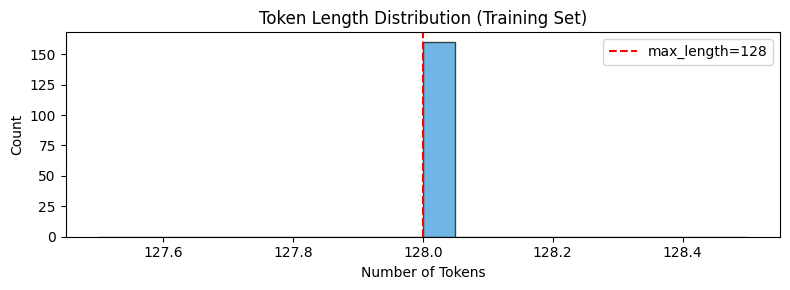


Dynamic padding in action (batch of 4):
  Example 0: 24 real tokens + 104 padding = 128 total
  Example 1: 35 real tokens + 93 padding = 128 total
  Example 2: 32 real tokens + 96 padding = 128 total
  Example 3: 32 real tokens + 96 padding = 128 total


In [17]:
# =============================================================================
# DEMO: Inspect Tokenization Quality and Padding Behavior
# =============================================================================
# Before you build your own pipeline in Lab 1, let's look at what happens
# when we batch tokenized examples together with dynamic padding.

# Show token length distribution
token_lengths = [len(train_tokenized[i]['input_ids']) for i in range(len(train_tokenized))]
print("Token Length Statistics:")
print(f"  Min:    {min(token_lengths)}")
print(f"  Max:    {max(token_lengths)}")
print(f"  Mean:   {np.mean(token_lengths):.1f}")
print(f"  Median: {np.median(token_lengths):.1f}")

# Visualize distribution
fig, ax = plt.subplots(figsize=(8, 3))
ax.hist(token_lengths, bins=20, color='#3498db', edgecolor='black', alpha=0.7)
ax.axvline(128, color='red', linestyle='--', label='max_length=128')
ax.set_xlabel('Number of Tokens')
ax.set_ylabel('Count')
ax.set_title('Token Length Distribution (Training Set)')
ax.legend()
plt.tight_layout()
plt.show()

# Show how DataCollator pads a mini-batch
sample_batch = [train_tokenized[i] for i in range(4)]
collated = data_collator(sample_batch)
print(f"\nDynamic padding in action (batch of 4):")
for i in range(4):
    real_tokens = collated['attention_mask'][i].sum().item()
    total_tokens = len(collated['input_ids'][i])
    padding = total_tokens - real_tokens
    print(f"  Example {i}: {real_tokens} real tokens + {padding} padding = {total_tokens} total")

## Lab 1: Prepare Your Dataset (15 minutes)

### Your Task

Create a complete data preparation pipeline with analysis. Don't just
prepare the data — understand its characteristics and how tokenization
affects different transaction types.

### Steps

1. **Verify label distribution**: Print class counts for train and val splits.
   Are they balanced? If not, what problems could this cause during training?

2. **Truncation analysis by class**: For max_length in [64, 128, 256], count
   how many examples get truncated. But go further: split the analysis by
   fraud vs legitimate. Are fraud descriptions systematically longer?
   Print a table showing truncation rates per class per max_length.

3. **Token length analysis**: Compute the mean, median, and std of token
   lengths for fraud vs legitimate examples separately. Create a figure
   with side-by-side histograms (one for each class). Could token length
   alone be a useful feature for fraud detection?

4. **Dynamic padding efficiency**: Create a `DataCollatorWithPadding` and
   collate a batch of 8 examples. Compare the total number of tokens in the
   batch (with dynamic padding) vs what you'd get with fixed max_length=128
   padding. Compute the percentage of padding tokens saved.

5. **Round-trip verification**: Decode a tokenized example back to text.
   Compare it to the original. Note: DistilBERT is uncased, so expect
   lowercase output.

### Expected Output

- Label distribution table
- Truncation rates per class per max_length
- Side-by-side histograms of token lengths by class
- Padding efficiency comparison (dynamic vs fixed)
- Decoded text matching original (modulo case)

### Homework Extension

After class: investigate whether token length alone can predict fraud.
Train a simple logistic regression on token length and compare its
accuracy to the DistilBERT classifier.


--- Step 1: Label Distribution ---
Train Label Counts:
label
fraud         80
legitimate    80
Name: count, dtype: int64
Val Label Counts:
label
fraud         20
legitimate    20
Name: count, dtype: int64
Labels are balanced in both train and validation splits. No immediate concerns about class imbalance.

--- Step 2: Truncation Analysis by Class ---


/tmp/ipykernel_3948/3994821673.py:15: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  if train_label_counts[0] == train_label_counts[1] and val_label_counts[0] == val_label_counts[1]:


,max_length,fraud_truncated_count,fraud_truncated_rate,legit_truncated_count,legit_truncated_rate
0,64,0,0.0%,0,0.0%
1,128,0,0.0%,0,0.0%
2,256,0,0.0%,0,0.0%



Fraud Token Lengths: Mean=32.5, Median=32.0, Std=3.3
Legitimate Token Lengths: Mean=32.0, Median=31.0, Std=2.8


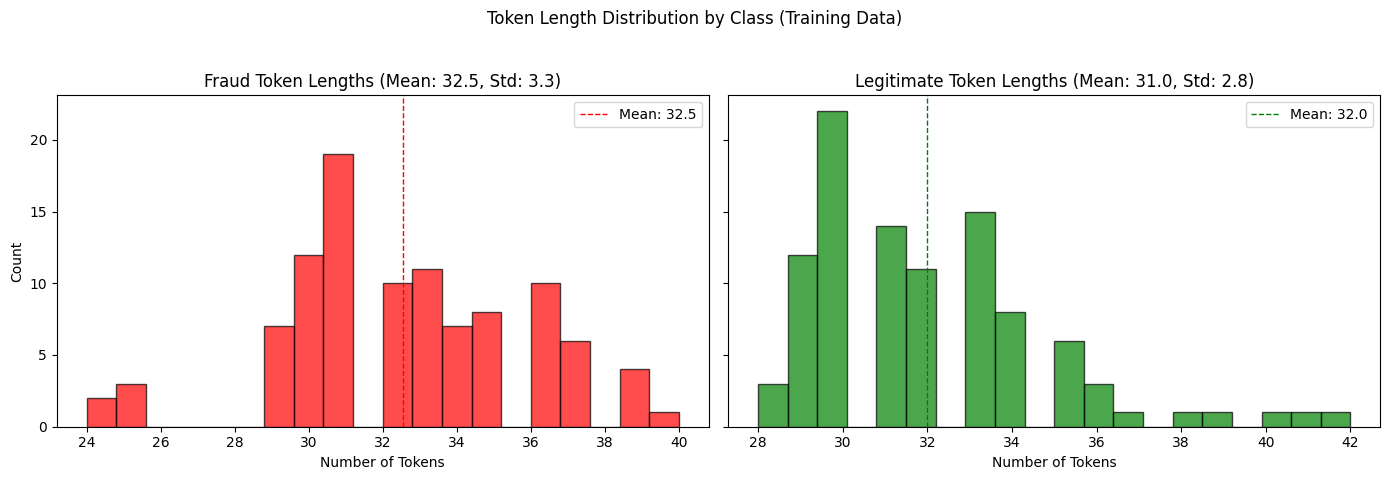


--- Step 4: Dynamic Padding Efficiency ---
Number of examples in batch: 8
Fixed max_length used during initial tokenization: 128
Max length in collated batch (actual longest in batch): 128
Total actual tokens (without any padding within batch): 253
Total tokens if padded to fixed_max_length (128) for this batch: 1024
Padding tokens saved (compared to fixed 128 padding): 771
Percentage of padding tokens saved: 75.29%

--- Step 5: Round-trip Verification ---
Original text (first training example): "Multiple rapid purchases totaling $10537 across 5 merchants in 35 minutes. None of these merchants in customer history."
Decoded text: "multiple rapid purchases totaling $ 10537 across 5 merchants in 35 minutes. none of these merchants in customer history."
Content Match (normalized): False

✅ Lab 1 complete!
   Data collator: DataCollatorWithPadding
   Fraud mean tokens: 32.5
   Legit mean tokens: 32.0


In [26]:
# =============================================================================
# LAB 1: PREPARE YOUR DATASET
# =============================================================================

# --- Step 1: Label distribution ---
print("\n--- Step 1: Label Distribution ---")
train_label_counts = train_split["label"].value_counts()
val_label_counts = val_split["label"].value_counts()

print("Train Label Counts:")
print(train_label_counts)
print("Val Label Counts:")
print(val_label_counts)

if train_label_counts[0] == train_label_counts[1] and val_label_counts[0] == val_label_counts[1]:
    print("Labels are balanced in both train and validation splits. No immediate concerns about class imbalance.")
else:
    print("Labels are not balanced. This could lead to biased models if not addressed (e.g., with weighted loss, over/undersampling).")

# --- Step 2: Truncation analysis BY CLASS ---
# For each max_length, count truncated examples separately for fraud vs legit
def get_token_length(text):
  # Hint: use tokenizer(text, truncation=False) to get untruncated token count
  return len(tokenizer(text, truncation=False)['input_ids'])

fraud_descriptions_full = train_df[train_df['label'] == 'fraud']['description'].tolist()
legit_descriptions_full = train_df[train_df['label'] == 'legitimate']['description'].tolist()

print("\n--- Step 2: Truncation Analysis by Class ---")
truncation_results = []

for max_len in [64, 128, 256]:
    fraud_untruncated_lengths = [get_token_length(desc) for desc in fraud_descriptions_full]
    legit_untruncated_lengths = [get_token_length(desc) for desc in legit_descriptions_full]

    fraud_truncated_count = sum(1 for l in fraud_untruncated_lengths if l > max_len)
    legit_truncated_count = sum(1 for l in legit_untruncated_lengths if l > max_len)

    total_fraud = len(fraud_descriptions_full)
    total_legit = len(legit_descriptions_full)

    truncation_results.append({
        'max_length': max_len,
        'fraud_truncated_count': fraud_truncated_count,
        'fraud_truncated_rate': f"{fraud_truncated_count / total_fraud:.1%}",
        'legit_truncated_count': legit_truncated_count,
        'legit_truncated_rate': f"{legit_truncated_count / total_legit:.1%}",
    })

truncation_df = pd.DataFrame(truncation_results)
display(truncation_df)

# --- Step 3: Token length analysis by class ---
# Compute token lengths for all training examples, split by label
# Create side-by-side histograms
# Hint: tokenizer(text, truncation=False)['input_ids'] gives you token IDs
fraud_lengths = [get_token_length(desc) for desc in fraud_descriptions_full]
legit_lengths = [get_token_length(desc) for desc in legit_descriptions_full]

# Calculate statistics
fraud_mean = np.mean(fraud_lengths)
fraud_median = np.median(fraud_lengths)
fraud_std = np.std(fraud_lengths)

legit_mean = np.mean(legit_lengths)
legit_median = np.median(legit_lengths)
legit_std = np.std(legit_lengths)

print(f"\nFraud Token Lengths: Mean={fraud_mean:.1f}, Median={fraud_median:.1f}, Std={fraud_std:.1f}")
print(f"Legitimate Token Lengths: Mean={legit_mean:.1f}, Median={legit_median:.1f}, Std={legit_std:.1f}")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

ax1.hist(fraud_lengths, bins=20, color='red', edgecolor='black', alpha=0.7)
ax1.axvline(fraud_mean, color='red', linestyle='dashed', linewidth=1, label=f'Mean: {fraud_mean:.1f}')
ax1.set_title(f'Fraud Token Lengths (Mean: {fraud_mean:.1f}, Std: {fraud_std:.1f})')
ax1.set_xlabel('Number of Tokens')
ax1.set_ylabel('Count')
ax1.legend()

ax2.hist(legit_lengths, bins=20, color='green', edgecolor='black', alpha=0.7)
ax2.axvline(legit_mean, color='green', linestyle='dashed', linewidth=1, label=f'Mean: {legit_mean:.1f}')
ax2.set_title(f'Legitimate Token Lengths (Mean: {legit_median:.1f}, Std: {legit_std:.1f})')
ax2.set_xlabel('Number of Tokens')
ax2.legend()

plt.suptitle('Token Length Distribution by Class (Training Data)')
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

# --- Step 4: Dynamic padding efficiency ---
# Create DataCollatorWithPadding and compare to fixed padding
lab_data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

print("\n--- Step 4: Dynamic Padding Efficiency ---")
# Get a batch of 8 examples from train_tokenized
if len(train_tokenized) < 8:
    print("Warning: Not enough examples in train_tokenized for a batch of 8. Using all available examples.")
    sample_batch_hf_dataset = train_tokenized[:]
else:
    sample_batch_hf_dataset = train_tokenized.select(range(8))

# Fix: Convert Dataset to a list of dictionaries for DataCollatorWithPadding
collated_batch = lab_data_collator(list(sample_batch_hf_dataset))

total_tokens_dynamic = collated_batch['attention_mask'].sum().item()
max_len_in_batch = collated_batch['input_ids'].shape[1]
num_examples = len(sample_batch_hf_dataset)
fixed_max_length_for_tokenization = 128 # The fixed max_length used during tokenization

# Calculate total tokens if fixed padding was used for a batch of this size
total_tokens_fixed_padding_batch = num_examples * fixed_max_length_for_tokenization

# Calculate padding if every example was padded to max_len_in_batch (actual max length in this batch)
total_tokens_fixed_to_batch_max = num_examples * max_len_in_batch

# Compute savings compared to the fixed max_length that was used during initial tokenization
padding_saved = total_tokens_fixed_padding_batch - total_tokens_dynamic
percentage_saved = (padding_saved / total_tokens_fixed_padding_batch) * 100

print(f"Number of examples in batch: {num_examples}")
print(f"Fixed max_length used during initial tokenization: {fixed_max_length_for_tokenization}")
print(f"Max length in collated batch (actual longest in batch): {max_len_in_batch}")
print(f"Total actual tokens (without any padding within batch): {total_tokens_dynamic}")
print(f"Total tokens if padded to fixed_max_length ({fixed_max_length_for_tokenization}) for this batch: {total_tokens_fixed_padding_batch}")
print(f"Padding tokens saved (compared to fixed {fixed_max_length_for_tokenization} padding): {padding_saved}")
print(f"Percentage of padding tokens saved: {percentage_saved:.2f}%")


# --- Step 5: Round-trip verification ---
print("\n--- Step 5: Round-trip Verification ---")
# Get the first example from the original (non-tokenized) train_dataset
original_text = train_dataset[0]['text']

# Get the first tokenized example from train_tokenized
first_tokenized_example = train_tokenized[0]

# Decode the input_ids back to text, skipping special tokens
sample_decoded = tokenizer.decode(first_tokenized_example['input_ids'], skip_special_tokens=True)

print(f"Original text (first training example): \"{original_text}\"")
print(f"Decoded text: \"{sample_decoded}\"")

# For robust comparison, normalize both strings (lowercase, split and join to handle whitespace/extra spaces)
original_normalized = ' '.join(original_text.lower().split())
decoded_normalized = ' '.join(sample_decoded.lower().split())
print(f"Content Match (normalized): {original_normalized == decoded_normalized}")

# Verification
if lab_data_collator is not None and fraud_lengths is not None:
    print("\n✅ Lab 1 complete!")
    print(f"   Data collator: {type(lab_data_collator).__name__}")
    print(f"   Fraud mean tokens: {np.mean(fraud_lengths):.1f}")
    print(f"   Legit mean tokens: {np.mean(legit_lengths):.1f}")
else:
    print("❌ Lab 1 incomplete — fill in the YOUR CODE sections above")

# Section 3: Fine-Tuning DistilBERT

Now the main event: we'll fine-tune DistilBERT to classify fraud.

The HuggingFace `Trainer` handles the training loop for us:
- Forward pass (model predictions)
- Loss calculation (cross-entropy)
- Backward pass (gradient computation)
- Parameter update (optimizer step)
- Evaluation on validation set
- Checkpointing (save best model)

We just need to configure it.

In [27]:
# =============================================================================
# DEMO: Define Training Configuration
# =============================================================================

training_args = TrainingArguments(
    output_dir='./fraud-classifier',           # Save checkpoints here
    num_train_epochs=3,                        # 3 passes through training data
    per_device_train_batch_size=16,            # Batch size per GPU
    per_device_eval_batch_size=16,             # Batch size for evaluation
    eval_strategy='epoch',                     # Evaluate after each epoch
    save_strategy='epoch',                     # Save checkpoint after each epoch
    learning_rate=2e-5,                        # Standard for BERT fine-tuning
    weight_decay=0.01,                         # Regularization
    load_best_model_at_end=True,               # Load best model when done
    metric_for_best_model='accuracy',          # Use accuracy to pick best
    logging_steps=10,                          # Log every 10 steps
    report_to='none',                          # Don't report to W&B etc.
    fp16=torch.cuda.is_available(),            # Use mixed precision on GPU
)

print("Training Configuration:")
print(f"  Epochs:        {training_args.num_train_epochs}")
print(f"  Batch size:    {training_args.per_device_train_batch_size}")
print(f"  Learning rate: {training_args.learning_rate}")
print(f"  FP16:          {training_args.fp16}")
print(f"  Device:        {'GPU' if torch.cuda.is_available() else 'CPU'}")

# Estimate training time
steps_per_epoch = len(train_tokenized) // training_args.per_device_train_batch_size
total_steps = steps_per_epoch * training_args.num_train_epochs
print(f"\n  Steps/epoch:   {steps_per_epoch}")
print(f"  Total steps:   {total_steps}")
print(f"  Est. time:     ~{total_steps * 0.3:.0f}s on T4 GPU")

Training Configuration:
  Epochs:        3
  Batch size:    16
  Learning rate: 2e-05
  FP16:          True
  Device:        GPU

  Steps/epoch:   10
  Total steps:   30
  Est. time:     ~9s on T4 GPU


In [29]:
# =============================================================================
# DEMO: Define Evaluation Metrics
# =============================================================================

accuracy_metric = evaluate.load('accuracy')


def compute_metrics(eval_pred):
    """Compute accuracy, precision, recall, F1 during training."""
    predictions, labels = eval_pred
    preds = np.argmax(predictions, axis=-1)
    precision, recall, f1, _ = precision_recall_fscore_support(
        labels, preds, average='binary'
    )
    acc = accuracy_score(labels, preds)
    return {
        'accuracy': acc,
        'precision': precision,
        'recall': recall,
        'f1': f1,
    }


# =============================================================================
# Helper: load a fresh model with frozen encoder
# =============================================================================
def load_frozen_model():
    """Load DistilBERT with frozen encoder — only classifier head is trainable."""
    m = AutoModelForSequenceClassification.from_pretrained(
        MODEL_NAME, num_labels=2,
        id2label=ID2LABEL, label2id=LABEL2ID
    )
    for param in m.distilbert.parameters():
        param.requires_grad = False
    return m


# =============================================================================
# DEMO: Create Trainer and TRAIN!
# =============================================================================

# Re-load model fresh with frozen encoder (in case we're re-running)
model = load_frozen_model()

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_tokenized,
    eval_dataset=val_tokenized,
    data_collator=data_collator, # Removed tokenizer=tokenizer
    compute_metrics=compute_metrics,
)

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Training classifier head only ({trainable:,} parameters)...")
print("=" * 50)
train_result = trainer.train()
print("=" * 50)
print(f"\n✅ Training complete!")
print(f"  Training loss: {train_result.training_loss:.4f}")
print(f"  Training time: {train_result.metrics['train_runtime']:.0f}s")


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Training classifier head only (592,130 parameters)...


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.683618,0.668518,0.525000,1.000000,0.050000,0.095238
2,0.667236,0.654138,0.775000,1.000000,0.550000,0.709677
3,0.654160,0.649341,0.825000,1.000000,0.650000,0.787879


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].



✅ Training complete!
  Training loss: 0.6683
  Training time: 18s


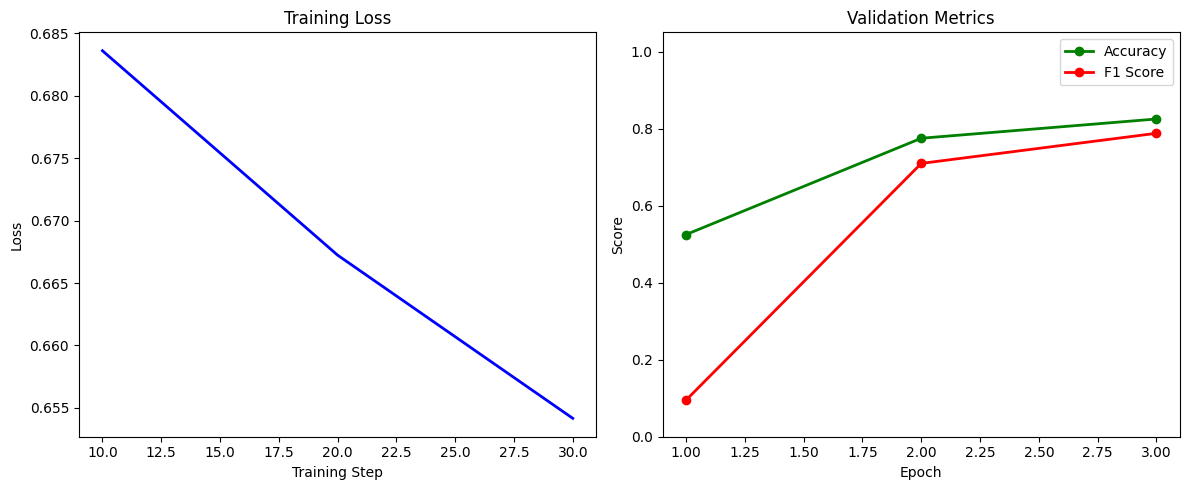

Final validation metrics (epoch 3):
  Accuracy:  82.5%
  Precision: 100.0%
  Recall:    65.0%
  F1 Score:  78.8%


In [30]:
# =============================================================================
# DEMO: Plot Training Metrics
# =============================================================================

# Extract training history
history = trainer.state.log_history

# Separate training and eval logs
train_logs = [h for h in history if 'loss' in h and 'eval_loss' not in h]
eval_logs = [h for h in history if 'eval_loss' in h]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Training loss
if train_logs:
    steps = [h['step'] for h in train_logs]
    losses = [h['loss'] for h in train_logs]
    ax1.plot(steps, losses, 'b-', linewidth=2)
    ax1.set_xlabel('Training Step')
    ax1.set_ylabel('Loss')
    ax1.set_title('Training Loss')

# Validation metrics per epoch
if eval_logs:
    epochs = list(range(1, len(eval_logs) + 1))
    val_acc = [h['eval_accuracy'] for h in eval_logs]
    val_f1 = [h['eval_f1'] for h in eval_logs]
    ax2.plot(epochs, val_acc, 'g-o', label='Accuracy', linewidth=2)
    ax2.plot(epochs, val_f1, 'r-o', label='F1 Score', linewidth=2)
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Score')
    ax2.set_title('Validation Metrics')
    ax2.legend()
    ax2.set_ylim(0, 1.05)

plt.tight_layout()
plt.show()

# Print final metrics
if eval_logs:
    final = eval_logs[-1]
    print(f"Final validation metrics (epoch {len(eval_logs)}):")
    print(f"  Accuracy:  {final['eval_accuracy']:.1%}")
    print(f"  Precision: {final['eval_precision']:.1%}")
    print(f"  Recall:    {final['eval_recall']:.1%}")
    print(f"  F1 Score:  {final['eval_f1']:.1%}")

Test Set Results (50 transactions)
              precision    recall  f1-score   support

  legitimate       0.74      0.97      0.84        29
       fraud       0.92      0.52      0.67        21

    accuracy                           0.78        50
   macro avg       0.83      0.74      0.75        50
weighted avg       0.81      0.78      0.76        50



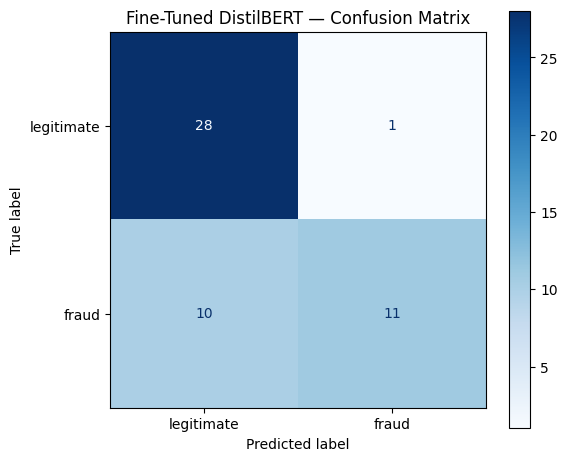


Errors (11/50):
  TXN-005: predicted 'legitimate', actual 'fraud'
    "Customer disputes charge of $2,100 at luxury jewelry store in Miami. Customer's ..."
  TXN-007: predicted 'legitimate', actual 'fraud'
    "Multiple small online purchases ($5-$15) at various digital stores within 30 min..."
  TXN-011: predicted 'legitimate', actual 'fraud'
    "Five gift card purchases of $500 each at different Walmart locations within one ..."
  TXN-012: predicted 'legitimate', actual 'fraud'
    "Online gambling deposit of $2,000 to an unlicensed offshore betting site. Custom..."
  TXN-016: predicted 'legitimate', actual 'fraud'
    "Account drained of $6,300 through a series of Zelle transfers to three unknown r..."
  TXN-018: predicted 'legitimate', actual 'fraud'
    "Two simultaneous transactions: $1,100 at a restaurant in London and $890 at a st..."
  TXN-019: predicted 'legitimate', actual 'fraud'
    "Refund of $2,500 processed to a different card than the original purchase. Origi..."
  T

In [31]:
# =============================================================================
# DEMO: Evaluate on the 50 Test Transactions
# =============================================================================
# These are the SAME 50 transactions from Week 13 — never seen during training.

test_results = trainer.predict(test_tokenized)
test_preds = np.argmax(test_results.predictions, axis=-1)
test_labels = test_results.label_ids

# Classification report
print("Test Set Results (50 transactions)")
print("=" * 50)
print(classification_report(
    test_labels, test_preds,
    target_names=['legitimate', 'fraud']
))

# Confusion matrix
fig, ax = plt.subplots(figsize=(6, 5))
cm = confusion_matrix(test_labels, test_preds)
disp = ConfusionMatrixDisplay(cm, display_labels=['legitimate', 'fraud'])
disp.plot(ax=ax, cmap='Blues')
ax.set_title('Fine-Tuned DistilBERT — Confusion Matrix')
plt.tight_layout()
plt.show()

# Show specific errors
test_df['predicted'] = [ID2LABEL[p] for p in test_preds]
test_df['correct'] = test_df['predicted'] == test_df['actual_label']
errors = test_df[~test_df['correct']]
print(f"\nErrors ({len(errors)}/{len(test_df)}):")
for _, row in errors.iterrows():
    print(f"  {row['id']}: predicted '{row['predicted']}', actual '{row['actual_label']}'")
    print(f"    \"{row['description'][:80]}...\"")

> **Think About It**: We fine-tuned on synthetic data generated by an LLM
> (Claude Haiku in Week 13). This is a form of **model distillation** — a large
> model's knowledge transferred to a smaller one via its labels. What risks
> does this introduce? What if the synthetic data has biases that real fraud
> data doesn't? How would you validate on REAL transactions before deploying?

In [33]:
# =============================================================================
# DEMO: Understanding Learning Rate Impact (Quick Experiment)
# =============================================================================
# Before Lab 2, let's see WHY learning rate matters so much for fine-tuning.
# We'll train for just a few steps with an absurdly high LR vs our standard LR.

# Dangerous LR: 1e-2 (way too high for classifier head training)
bad_args = TrainingArguments(
    output_dir='./fraud-bad-lr', num_train_epochs=1,
    per_device_train_batch_size=16, per_device_eval_batch_size=16,
    eval_strategy='epoch', learning_rate=1e-2,  # Way too high!
    weight_decay=0.01, logging_steps=5, report_to='none',
    fp16=torch.cuda.is_available(),
)

bad_model = load_frozen_model()
bad_trainer = Trainer(
    model=bad_model, args=bad_args,
    train_dataset=train_tokenized, eval_dataset=val_tokenized,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
)

print("Training with lr=1e-2 (intentionally too high)...")
bad_trainer.train()
bad_eval = bad_trainer.evaluate()

print(f"\n{'='*50}")
print(f"lr=2e-5 (our demo):    accuracy = {eval_logs[-1]['eval_accuracy']:.1%}")
print(f"lr=1e-2 (too high):    accuracy = {bad_eval['eval_accuracy']:.1%}")
print(f"{'='*50}")
print("\nToo-high LR destroys the classifier head weights before they converge.")
print("Even though the encoder is frozen, the head still needs a gentle learning rate.")
print("Typical range for transfer learning: 1e-5 to 5e-5.")

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Training with lr=1e-2 (intentionally too high)...


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.089104,0.030600,1.000000,1.000000,1.000000,1.000000


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


lr=2e-5 (our demo):    accuracy = 82.5%
lr=1e-2 (too high):    accuracy = 100.0%

Too-high LR destroys the classifier head weights before they converge.
Even though the encoder is frozen, the head still needs a gentle learning rate.
Typical range for transfer learning: 1e-5 to 5e-5.



--- Training with Learning Rate: 1e-05 ---


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
classifier.out_proj.bias        | MISSING    | 
classifier.dense.bias           | MISSING    | 
classifier.out_proj.weight      | MISSING    | 
classifier.dense.weight         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.701578,0.700513,0.500000,0.000000,0.000000,0.000000


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


...

RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
classifier.out_proj.bias        | MISSING    | 
classifier.dense.bias           | MISSING    | 
classifier.out_proj.weight      | MISSING    | 
classifier.dense.weight         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.708447,0.694678,0.500000,0.500000,1.000000,0.666667



--- Lab 2 Summary ---


,learning_rate,train_loss,test_accuracy,test_f1
0,0.00001,0.701578,0.58,0.000000
1,0.00002,0.713715,0.42,0.591549
2,0.00005,0.708447,0.42,0.591549



Best model (LR=2e-05) metrics:
  Accuracy: 42.0%
  F1 Score: 59.2%


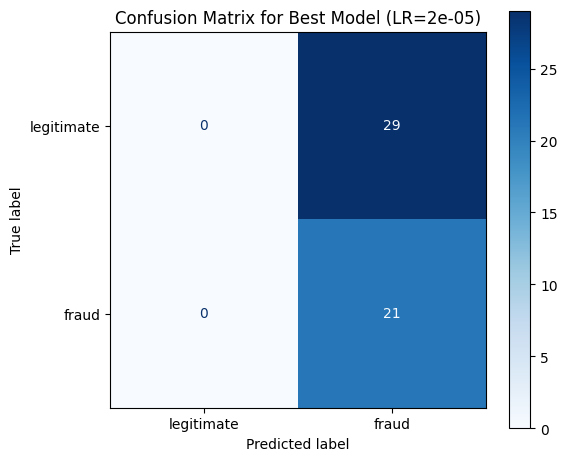


✅ Lab 2 complete!


In [46]:
# =============================================================================
# LAB 2: FINE-TUNE YOUR CLASSIFIER
# =============================================================================

# Initialize variables for the learning rate sweep
learning_rates = [1e-5, 2e-5, 5e-5]
lab2_results = []
best_test_f1 = -1.0 # Initialize to a low value to ensure first model is set as best
best_preds_for_cm = None
best_labels_for_cm = None
best_lr = None

# Define MODEL_NAME and the load_frozen_model function once outside the loop
MODEL_NAME = 'roberta-base'

def load_frozen_model():
  m = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME, num_labels=2,
    id2label=ID2LABEL, label2id=LABEL2ID
  )
  # Freeze roberta parameters
  for param in m.roberta.parameters():
      param.requires_grad = False
  return m

# =============================================================================
# LAB 2: Fine-tuning loop for different learning rates
# =============================================================================

for lr in learning_rates:
    print(f"\n--- Training with Learning Rate: {lr} ---")
    # Create TrainingArguments with this learning rate (1 epoch)
    args = TrainingArguments(
        output_dir=f'./fraud-classifier-lr-{lr}',           # Save checkpoints here
        num_train_epochs=2,                                  # 1 epoch for speed during experiment
        per_device_train_batch_size=16,
        per_device_eval_batch_size=16,
        eval_strategy='epoch',
        save_strategy='no',                                  # Don't save model for every LR trial
        learning_rate=lr,                                    # Use current learning rate from loop
        weight_decay=0.01,
        load_best_model_at_end=False,                        # Not loading best model for quick LR comparison
        metric_for_best_model='f1',                          # Use F1 to pick best for potentially imbalanced data
        logging_steps=10,
        report_to='none',
        fp16=torch.cuda.is_available(),
    )

    fresh_model = load_frozen_model() # Load fresh model for each LR experiment

    # Create Trainer and train
    lab_trainer = Trainer(
        model=fresh_model,
        args=args,
        train_dataset=train_tokenized,
        eval_dataset=val_tokenized, # Use validation set for eval during training
        data_collator=data_collator,
        compute_metrics=compute_metrics,
    )

    train_output = lab_trainer.train()
    train_loss = train_output.training_loss

    # Evaluate on test set
    test_results_obj = lab_trainer.predict(test_tokenized)
    test_preds = np.argmax(test_results_obj.predictions, axis=-1)
    test_labels = test_results_obj.label_ids

    # Compute metrics using the helper function
    metrics = compute_metrics((test_results_obj.predictions, test_labels))
    test_acc = metrics['accuracy']
    test_f1 = metrics['f1']

    lab2_results.append({
        'learning_rate': lr,
        'train_loss': train_loss,
        'test_accuracy': test_acc,
        'test_f1': test_f1,
    })

    # Keep track of the best model's predictions for the confusion matrix
    if test_f1 > best_test_f1:
        best_test_f1 = test_f1
        best_preds_for_cm = test_preds
        best_labels_for_cm = test_labels
        best_lr = lr

# Create summary table
summary_df = pd.DataFrame(lab2_results)

# Create confusion matrix for best model
print("\n--- Lab 2 Summary ---")
display(summary_df)

if best_preds_for_cm is not None:
    print(f"\nBest model (LR={best_lr}) metrics:")
    best = summary_df.loc[summary_df['learning_rate'] == best_lr].iloc[0]
    print(f"  Accuracy: {best['test_accuracy']:.1%}")
    print(f"  F1 Score: {best['test_f1']:.1%}")

    fig, ax = plt.subplots(figsize=(6, 5))
    cm = confusion_matrix(best_labels_for_cm, best_preds_for_cm)
    disp = ConfusionMatrixDisplay(cm, display_labels=['legitimate', 'fraud'])
    disp.plot(ax=ax, cmap='Blues')
    ax.set_title(f'Confusion Matrix for Best Model (LR={best_lr})')
    plt.tight_layout()
    plt.show()

    print("\n✅ Lab 2 complete!")
else:
    print("❌ Lab 2 incomplete — something went wrong with training models.")

## Lab 2: Fine-Tune Your Classifier (15 minutes)

### Your Task

Experiment with different training configurations to see how they affect
accuracy on the 50-transaction test set. Remember: we freeze the encoder
and only train the classifier head.

### Steps

1. **Experiment with learning rate**: Try 1e-5 vs 2e-5 vs 5e-5
2. **For each LR**: use `load_frozen_model()` to get a fresh model with frozen encoder
3. **Train for 1 epoch** each (for speed), evaluate on test set
4. **Record test accuracy and F1** for each configuration
5. **Create a summary table**: learning rate, train loss, test accuracy, F1
6. **Create a confusion matrix** for your best model

### Expected Output

- Table with 3 rows (one per learning rate)
- Confusion matrix for the best model
- Best learning rate identified

### Homework Extension

After class: try varying epochs (1 vs 3 vs 5 vs 10) with your best learning rate.
Plot accuracy vs epochs. At what point does the model overfit (val accuracy drops)?

# Section 4: The Grand Comparison — When to Fine-Tune?

Let's put it all together. We've tried multiple approaches across 4 weeks.
How do they compare?

In [ ]:
# =============================================================================
# DEMO: Grand Comparison — All Approaches Across 4 Weeks
# =============================================================================

# Results from previous weeks (approximate — students can fill in actuals)
comparison = pd.DataFrame([
    {'Week': 11, 'Approach': 'OpenAI GPT-4o-mini', 'Type': 'Cloud API (prompted)',
     'Accuracy': 0.94, 'Latency': '~1.0s', 'Cost_per_call': '$0.0003', 'Training': 'None'},
    {'Week': 12, 'Approach': 'GPT-2 (local)', 'Type': 'Local (prompted)',
     'Accuracy': 0.50, 'Latency': '~0.5s', 'Cost_per_call': 'Free', 'Training': 'None'},
    {'Week': 12, 'Approach': 'Flan-T5 prompted', 'Type': 'Local (prompted)',
     'Accuracy': 0.75, 'Latency': '~0.3s', 'Cost_per_call': 'Free', 'Training': 'None'},
    {'Week': 12, 'Approach': 'DistilBERT-SST2 proxy', 'Type': 'Local (fine-tuned for other task)',
     'Accuracy': 0.62, 'Latency': '~0.05s', 'Cost_per_call': 'Free', 'Training': 'None'},
    {'Week': 13, 'Approach': 'Bedrock Claude Haiku', 'Type': 'Managed AWS (prompted)',
     'Accuracy': 0.94, 'Latency': '~0.8s', 'Cost_per_call': '$0.0002', 'Training': 'None'},
    {'Week': 13, 'Approach': 'Bedrock Nova Lite', 'Type': 'Managed AWS (prompted)',
     'Accuracy': 0.88, 'Latency': '~0.5s', 'Cost_per_call': '$0.00003', 'Training': 'None'},
    {'Week': 14, 'Approach': 'DistilBERT fine-tuned', 'Type': 'Local (fine-tuned for fraud)',
     'Accuracy': test_df['correct'].mean(), 'Latency': '~0.05s', 'Cost_per_call': 'Free*',
     'Training': f'{train_result.metrics["train_runtime"]:.0f}s on T4'},
])

print("Grand Comparison: Fraud Classification Across 4 Weeks")
print("=" * 80)
display(comparison)

print("\n* Free at inference — training cost was GPU compute time only")
print("\nKey insight: Fine-tuning a small model (67M params) gives you")
print("   near-cloud-API accuracy at local-model speed and cost.")

In [ ]:
# =============================================================================
# DEMO: When to Fine-Tune vs When to Prompt
# =============================================================================

decision_framework = """
DECISION FRAMEWORK: Fine-Tune or Prompt?
=========================================

Choose PROMPT ENGINEERING when:
  You have < 50 labeled examples
  The task changes frequently
  You need reasoning/explanations (not just labels)
  Budget allows cloud API costs at your volume
  You need it working TODAY (no training time)

Choose TRANSFER LEARNING (freeze encoder + train head) when:
  You have 100+ labeled examples (or can generate synthetic data)
  The task is stable (won't change monthly)
  You need fast inference (real-time scoring)
  You need to minimize per-call costs at scale
  You need a consistent output format (just labels, no variance)
  Data privacy requires keeping everything on-premise

The HYBRID approach (what we did!):
  1. Use a big model (Bedrock Claude) to GENERATE training data
  2. Freeze a small model's encoder (DistilBERT) and train a classifier head
  3. Deploy the small model for production inference
  -> Best of both worlds: big model quality, small model cost
"""

print(decision_framework)

> **Think About It**: We used Claude Haiku (via Bedrock) to generate synthetic
> training data, then fine-tuned DistilBERT on that data. This is a form of
> **knowledge distillation**. The fine-tuned model can now run without any API
> calls. At 1 million transactions per month, what's the cost difference between
> calling Bedrock Claude Haiku vs running your fine-tuned DistilBERT locally?

## A Note on PEFT, LoRA, and Distillation

In this session, we froze the DistilBERT encoder and trained only the
classifier head (~590K parameters out of 67M total). This is classic
**transfer learning**. But there are more advanced techniques:

### Parameter-Efficient Fine-Tuning (PEFT/LoRA)

**LoRA** adds small trainable "adapter" matrices to frozen layers, letting
you capture task-specific patterns deeper in the model without updating
all parameters.

| Technique | What It Does | When to Use |
|-----------|-------------|-------------|
| **Freeze encoder + train head** (today) | Only train classification head | Small models, simple tasks |
| **LoRA** | Add small adapter matrices to frozen encoder | Medium models (1B-7B params) |
| **QLoRA** | LoRA + 4-bit quantization | Large models (7B+ params), limited GPU |
| **Full fine-tuning** | Update all parameters | When you have tons of data and compute |

See: `week_14_optional_peft_lora.ipynb`

### Knowledge Distillation

What we did today (using a large model's outputs to train a smaller one) is
actually a form of **distillation** — a large model's knowledge transferred
to a smaller one via its labels. Formal distillation goes further — training
the student model to match the teacher's probability distributions, not just
its hard labels.

See: `week_14_optional_distillation.ipynb`

In [ ]:
# =============================================================================
# QUICK PEEK: What LoRA Code Looks Like (don't worry about details!)
# =============================================================================
# This is just a preview — the optional notebook goes deeper.
# We froze the entire encoder today. LoRA takes a different approach:
# instead of freezing, it adds tiny trainable "adapter" matrices.

frozen_params = sum(p.numel() for p in model.parameters() if not p.requires_grad)
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
total_params = frozen_params + trainable_params

print("Our approach today (freeze encoder, train head only):")
print(f"  Trainable parameters: {trainable_params:,} ({trainable_params/total_params:.2%} of model)")
print(f"  Frozen parameters:    {frozen_params:,}")
print()
print("LoRA approach (optional notebook):")
lora_params = 2 * 768 * 8 * 6  # rank=8, 6 attention layers (approximate)
print(f"  Trainable parameters: ~{lora_params:,} ({lora_params/total_params:.1%} of model)")
print(f"  Frozen parameters:    ~{total_params - lora_params:,}")
print()
print("Key insight: Both approaches train <1% of parameters.")
print("   LoRA is essential for LARGE models (7B+ params) where even loading")
print("   the full model requires multiple GPUs.")

# Summary: What We Learned Today

## Key Takeaways

### Transfer Learning
- Pre-trained models already understand language — we freeze them
- We add a small classification head and train ONLY that on our data
- DistilBERT: 67M frozen encoder params + ~590K trainable head params
- Training is fast because we're only updating <1% of parameters

### The Full Pipeline
1. **Generate synthetic data** with a large model (Week 13, Bedrock)
2. **Tokenize and prepare** with HuggingFace (today)
3. **Freeze encoder + train classifier head** with HuggingFace Trainer (today)
4. **Evaluate** against prompted approaches (today)

### When to Fine-Tune
- Lots of labeled data + stable task + need speed/low cost → transfer learning
- Few examples + changing task + need explanations → prompt engineering
- Hybrid: big model generates labels → freeze small model + train head

## The Bigger Picture

![Week Progression](https://github.com/axel-sirota/bread-financial-academy/blob/main/exercises/week_14_training_ai_models/charts/week_progression.png?raw=1)

| Week | What We Did |
|------|------------|
| 11 | Cloud APIs (OpenAI, Anthropic), prompting patterns |
| 12 | Local HuggingFace models, evaluation, error analysis |
| 13 | Bedrock managed models, Knowledge Bases, synthetic data, DeepEval |
| **14** | **Transfer learning: froze DistilBERT encoder, trained fraud classifier head** |
| 15-16 | Agentic AI — ReAct agents, LangChain, multi-agent systems |

# Homework & Optional Labs

## Homework (Complete before next session)

### Homework 1: Hyperparameter Sweep
Try 5 combinations of learning rate x epochs:
- lr in {1e-5, 2e-5, 5e-5}, epochs in {1, 3, 5}
Create a heatmap showing accuracy for each combination.

### Homework 2: More Training Data
If you have Week 13's Bedrock access, generate 200 more synthetic transactions.
Retrain with the larger dataset. Does accuracy improve? By how much?

### Homework 3: Error Analysis
Take the test set errors from your best model. Why did they fail?
Are the misclassified transactions ambiguous even for humans?
Compare error patterns to Week 12's prompt-based error analysis.

## Optional Labs

### Optional 1: PEFT/LoRA Fine-Tuning
See `week_14_optional_peft_lora.ipynb` for:
- Install peft and bitsandbytes
- LoRA configuration (r, alpha, target_modules)
- Fine-tune Flan-T5 with LoRA adapters
- Compare: full fine-tuning vs LoRA (param count, memory, accuracy)

### Optional 2: Knowledge Distillation
See `week_14_optional_distillation.ipynb` for:
- Formal distillation with soft labels (temperature scaling)
- Train a student model on teacher probability distributions
- Compare: hard labels vs soft labels training
- When distillation outperforms standard fine-tuning

# Great Work Today!

You've completed Week 14 of the AI for Data Scientists Academy.

**What you accomplished:**
- Prepared text data for fine-tuning with HuggingFace tokenizers
- Fine-tuned DistilBERT for binary fraud classification
- Compared fine-tuned model against prompted approaches from Weeks 11-13
- Built a decision framework for when to fine-tune vs prompt

## Coming Up Next

- **Weeks 15-16**: Agentic AI — ReAct agents, LangChain, LangGraph
- **Weeks 17-18**: RAG — build retrieval pipelines (beyond Bedrock Knowledge Bases)
- **Weeks 19-20**: MLOps — DVC, CI/CD, monitoring

## Resources

- [HuggingFace Fine-Tuning Tutorial](https://huggingface.co/docs/transformers/training)
- [HuggingFace Trainer Documentation](https://huggingface.co/docs/transformers/main_classes/trainer)
- [DistilBERT Paper](https://arxiv.org/abs/1910.01108)
- [PEFT Library](https://huggingface.co/docs/peft)

See you in Week 15!